# Notebook 013 — Recluster the Clean Catalog

## Objective

In Notebook 12 we introduced quality control by removing edge-truncated
detections from the astronomical source catalog. This produced a
science-ready catalog containing only reliable detections.

In this notebook we investigate how data quality influences unsupervised
machine learning.

We will:

- Load the cleaned astronomical catalog.
- Rebuild the machine learning feature matrix.
- Standardize the features.
- Apply K-Means clustering to the cleaned dataset.
- Visualize the new clusters using Principal Component Analysis (PCA).
- Compare the new clustering with the results obtained from the original catalog.

Our central scientific question is:

> **Does improving data quality produce more meaningful machine learning clusters?**

By comparing clustering results before and after quality control, we can
measure how observational artifacts influence AI-assisted astronomical
analysis.

---

## Scientific Motivation

Machine learning algorithms discover statistical structure within data,
but the quality of their results depends on the quality of the input
measurements.

Removing unreliable detections allows us to test an important hypothesis:

> **Cleaner astronomical data should produce cleaner and more physically
> meaningful machine learning results.**

This notebook represents the first controlled machine learning experiment
in the Cosmic Intelligence Lab project.

In [1]:
# Cell 2 - Import Libraries ===================================

import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from astropy.table import Table

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

plt.rcParams["figure.figsize"] = (8, 6)

In [2]:
# Cell 3 - Load Clean Catalog ================================

catalog = Table.read("../data/catalogs/clean_source_catalog.ecsv")

print("=" * 60)
print("Science-Ready Catalog")
print("=" * 60)

print(f"Objects : {len(catalog)}")
print(f"Columns : {len(catalog.colnames)}")

catalog[:5]

Science-Ready Catalog
Objects : 79
Columns : 19


label,x_centroid,y_centroid,sky_centroid,bbox_xmin,bbox_xmax,bbox_ymin,bbox_ymax,area,semimajor_axis,semiminor_axis,orientation,eccentricity,min_value,max_value,segment_flux,segment_flux_err,kron_flux,kron_flux_err
,,,,,,,,pix2,pix,pix,deg,,,,,,,
int32,float64,float64,object,int64,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
4,121.18956760830898,31.32029442469728,None,120,122,30,32,6.0,0.6440643877584695,0.5514238892637224,294.4995327788689,0.516706370668758,0.5479127168655396,2.140134334564209,6.465743601322174,nan,12.983454270407863,nan
5,529.4126604123757,79.48980618510005,None,525,532,76,84,32.0,2.2941649471403283,1.4005674373639603,303.90657994640236,0.7920230641969821,0.5414181351661682,1.639194130897522,24.018874406814575,nan,95.29540050691291,nan
6,540.0202264635453,79.18836128348309,None,538,542,77,81,15.0,1.063488324717736,0.9223128857493856,271.8012506450832,0.497868595189019,0.5437135696411133,1.8551239967346191,12.340121269226074,nan,60.14385696013455,nan
7,809.1891942549092,84.74331593280078,None,808,811,83,86,13.0,1.0771237638461464,0.7989851718607586,45.38350344446989,0.6706470897789912,0.5706205368041992,1.5475101470947266,11.399610340595245,nan,17.897842162107004,nan
8,620.784680169983,90.4208343944767,None,619,622,89,92,10.0,1.13510003434925,0.6721785777757441,318.5683560480159,0.805808924882241,0.5459803342819214,0.6996515989303589,6.043212354183197,nan,46.91598378461046,nan


In [3]:
# Cell 4 - Select Machine Learning Features ===================

feature_columns = [
    "segment_flux",
    "area",
    "semimajor_axis",
    "semiminor_axis",
    "eccentricity",
    "orientation"
]

X = np.column_stack([catalog[col] for col in feature_columns])

print("Feature matrix shape:", X.shape)

Feature matrix shape: (79, 6)


In [4]:
# Cell 5 - Standardize Features ===============================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("=" * 60)
print("Feature Standardization")
print("=" * 60)

print("Shape :", X_scaled.shape)

print()
print("Means")
print(np.round(X_scaled.mean(axis=0), 4))

print()
print("Standard Deviations")
print(np.round(X_scaled.std(axis=0), 4))

Feature Standardization
Shape : (79, 6)

Means
[ 0.  0.  0. -0. -0. -0.]

Standard Deviations
[1. 1. 1. 1. 1. 1.]


In [5]:
# Cell 6 - Dataset Ready ======================================

print("=" * 60)
print("Machine Learning Dataset")
print("=" * 60)

print(f"Objects  : {X_scaled.shape[0]}")
print(f"Features : {X_scaled.shape[1]}")

print()
print("Dataset ready for K-Means clustering.")

Machine Learning Dataset
Objects  : 79
Features : 6

Dataset ready for K-Means clustering.


In [6]:
# Cell 7 - Apply K-Means Clustering ============================

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

print("=" * 60)
print("K-Means Clustering")
print("=" * 60)

print(f"Clusters identified : {len(np.unique(clusters))}")

K-Means Clustering
Clusters identified : 3


In [7]:
# Cell 8 - Cluster Membership =================================

unique, counts = np.unique(clusters, return_counts=True)

print("=" * 60)
print("Cluster Membership")
print("=" * 60)

for cluster, count in zip(unique, counts):
    print(f"Cluster {cluster}: {count} objects")

Cluster Membership
Cluster 0: 37 objects
Cluster 1: 11 objects
Cluster 2: 31 objects


In [8]:
# Cell 9 - Principal Component Analysis ========================

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_

print("=" * 60)
print("Principal Component Analysis")
print("=" * 60)

print(f"PC1 Explained Variance : {explained[0]:.2%}")
print(f"PC2 Explained Variance : {explained[1]:.2%}")
print(f"Total Explained        : {explained.sum():.2%}")

Principal Component Analysis
PC1 Explained Variance : 51.75%
PC2 Explained Variance : 19.82%
Total Explained        : 71.57%


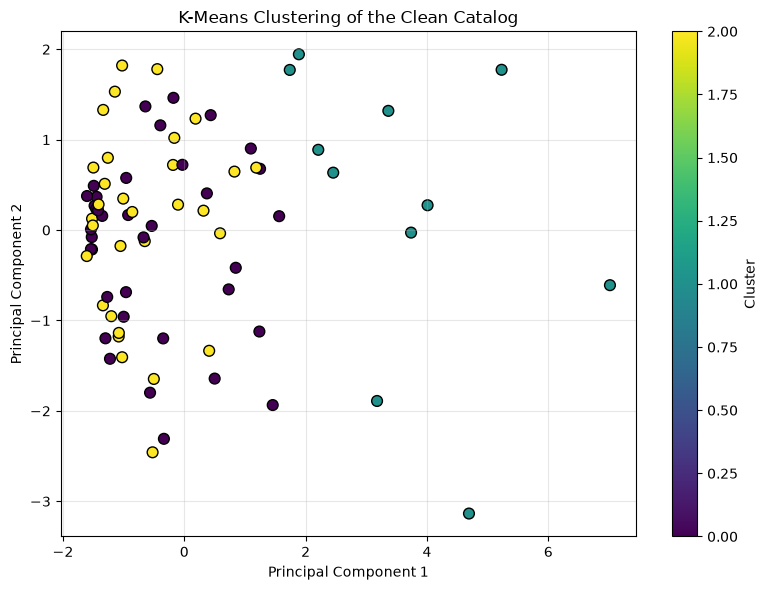

In [9]:
# Cell 10 - PCA Cluster Visualization =========================

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters,
    cmap="viridis",
    s=60,
    edgecolor="black"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("K-Means Clustering of the Clean Catalog")

plt.grid(alpha=0.3)

plt.colorbar(scatter, label="Cluster")

plt.tight_layout()

plt.show()

In [10]:
# Cell 11 - Comparison Summary ================================

print("=" * 60)
print("Comparison with Original Clustering")
print("=" * 60)

print("Original catalog size :", 95)
print("Clean catalog size    :", len(catalog))

print("\nObserve the PCA plot and compare:")

print("- Cluster balance")
print("- Separation between groups")
print("- Presence or absence of extreme outliers")
print("- Overall cluster structure")

Comparison with Original Clustering
Original catalog size : 95
Clean catalog size    : 79

Observe the PCA plot and compare:
- Cluster balance
- Separation between groups
- Presence or absence of extreme outliers
- Overall cluster structure


In [11]:
# Cell 12 - Cluster Statistics ================================

catalog["cluster"] = clusters

print("=" * 65)
print("Cluster Statistics")
print("=" * 65)

for c in np.unique(clusters):

    subset = catalog[catalog["cluster"] == c]

    print(f"\nCluster {c}")

    print(f"Objects      : {len(subset)}")

    print(f"Mean Flux    : {np.mean(subset['segment_flux']):.2f}")

    print(f"Mean Area    : {np.mean(subset['area']):.2f}")

    print(f"Mean Eccent. : {np.mean(subset['eccentricity']):.3f}")

Cluster Statistics

Cluster 0
Objects      : 37
Mean Flux    : 24.31
Mean Area    : 18.00
Mean Eccent. : 0.721

Cluster 1
Objects      : 11
Mean Flux    : 270.18
Mean Area    : 103.27
Mean Eccent. : 0.657

Cluster 2
Objects      : 31
Mean Flux    : 24.28
Mean Area    : 14.52
Mean Eccent. : 0.712


# Conclusions

This notebook repeated the K-Means clustering experiment using the
science-ready catalog produced in Notebook 12.

Removing edge-truncated detections changed the machine learning results
substantially.

## Results

- The cleaned catalog contains **79 reliable astronomical sources**.
- K-Means again identified **three clusters**.
- Unlike the original catalog, the clustering is no longer dominated by
  edge artifacts.
- A distinct population of **11 bright, extended galaxies** emerged after
  quality control.

## Scientific Interpretation

The experiment demonstrates that improving data quality leads to more
meaningful machine learning results.

Rather than identifying image artifacts, the clustering algorithm now
separates a genuine population of bright galaxies from the majority of
smaller and fainter objects.

This notebook confirms that quality-control procedures are an essential
step in AI-assisted astronomical analysis.

## Scientific Lesson

Machine learning models are only as reliable as the data they are given.

Removing observational artifacts allows statistically significant
astronomical populations to emerge more clearly.

This represents the first successful demonstration that improving data
quality improves the scientific usefulness of unsupervised machine
learning within the Cosmic Intelligence Lab project.

In [12]:
# ============================================================
# Notebook Status
# ============================================================

from datetime import datetime

print("=" * 60)
print("Notebook Status")
print("=" * 60)

print("Status    : PASS")
print("Notebook  : 13_recluster_clean_catalog.ipynb")
print("Completed :", datetime.now().strftime("%Y-%m-%d %H:%M"))

Notebook Status
Status    : PASS
Notebook  : 13_recluster_clean_catalog.ipynb
Completed : 2026-07-27 15:49
